<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/data_loading_moncef.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn

In [39]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/compound"
print(os.listdir(dataset_path))

['README.txt', 'Annotation', 'Image', 'Feature', 'EmoLabel']


In [5]:
print(os.listdir("/content/drive/MyDrive/compound/EmoLabel"))

['list_patition_label.txt']


In [6]:

label_file = "/content/drive/MyDrive/compound/EmoLabel/list_patition_label.txt"

labels_dict = {}

with open(label_file, "r") as f:
    for line in f:
        parts = line.strip().split()
        img_name = parts[0]
        label = int(parts[1])
        labels_dict[img_name] = label

print("Nombre de labels :", len(labels_dict))

Nombre de labels : 3954


In [7]:
image_folder = "/content/drive/MyDrive/compound/Image"

In [8]:
train_images = []
test_images = []

with open(label_file, "r") as f:
    for line in f:
        parts = line.strip().split()
        img_name = parts[0]
        label = int(parts[1])

        if "train" in img_name:
            train_images.append(img_name)
        else:
            test_images.append(img_name)

print("Train:", len(train_images))
print("Test:", len(test_images))

Train: 3162
Test: 792


In [9]:
for i in range(5):
    img_name = train_images[i]
    img_path = os.path.join(image_folder, img_name)
    print(img_path)

/content/drive/MyDrive/compound/Image/train_0001.jpg
/content/drive/MyDrive/compound/Image/train_0002.jpg
/content/drive/MyDrive/compound/Image/train_0003.jpg
/content/drive/MyDrive/compound/Image/train_0004.jpg
/content/drive/MyDrive/compound/Image/train_0005.jpg


In [10]:
import cv2

test_path = "/content/drive/MyDrive/compound/Image/train_0001.jpg"

img = cv2.imread(test_path)

print(img)


None


In [11]:
from PIL import Image
import numpy as np

IMG_SIZE = 224

def load_images(image_list):
    images = []
    labels = []

    for img_name in image_list:
        img_path = os.path.join(image_folder, img_name)

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img)

            images.append(img)
            labels.append(labels_dict[img_name])

        except:
            continue

    return np.array(images), np.array(labels)


In [12]:
X_train, y_train = load_images(train_images)
print(X_train.shape)

(0,)


In [13]:
print("Exemple train_images :", train_images[:5])
print("Exemple fichiers réels :", os.listdir(image_folder)[:5])

Exemple train_images : ['train_0001.jpg', 'train_0002.jpg', 'train_0003.jpg', 'train_0004.jpg', 'train_0005.jpg']
Exemple fichiers réels : ['aligned.zip', 'original.zip', 'original', 'aligned']


In [14]:
image_folder = "/content/drive/MyDrive/compound/Image/aligned"

In [15]:
X_train, y_train = load_images(train_images)
print(X_train.shape)


(0,)


In [16]:
print(os.listdir("/content/drive/MyDrive/compound/Image/aligned")[:10])

['train_0973_aligned.jpg', 'train_0972_aligned.jpg', 'train_0970_aligned.jpg', 'train_0971_aligned.jpg', 'train_0974_aligned.jpg', 'train_0976_aligned.jpg', 'train_0977_aligned.jpg', 'train_0975_aligned.jpg', 'train_0979_aligned.jpg', 'train_0978_aligned.jpg']


In [17]:
from PIL import Image
import numpy as np
import os

IMG_SIZE = 224

def load_images(image_list):
    images = []
    labels = []

    for img_name in image_list:

        # 🔥 ajouter _aligned
        real_name = img_name.replace(".jpg", "_aligned.jpg")

        img_path = os.path.join(image_folder, real_name)

        if not os.path.exists(img_path):
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img)

            images.append(img)
            labels.append(labels_dict[img_name])

        except:
            continue

    print("Images chargées :", len(images))
    return np.array(images), np.array(labels)


In [18]:
X_train, y_train = load_images(train_images)
print(X_train.shape)

Images chargées : 3161
(3161, 224, 224, 3)


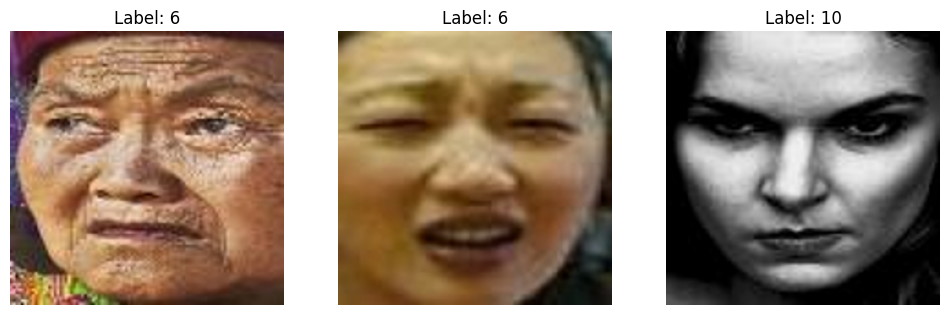

In [19]:
import matplotlib.pyplot as plt

# Let's look at the first 3 images you just loaded
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# 1. Normalize: Convert 0-255 to 0.0-1.0
X_train_norm = X_train.astype('float32') / 255.0

# 2. Split: 80% for training, 20% for validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_norm, y_train, test_size=0.2, random_state=42
)

# 3. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_final).permute(0, 3, 1, 2) # Change shape to (Batch, Channel, H, W)
y_train_tensor = torch.tensor(y_train_final).long() - 1 # Adjusting labels to 0-13

print(f"Ready to train on {X_train_tensor.shape[0]} images.")

Ready to train on 2528 images.


In [55]:
import torch.nn as nn
from torchvision import models

# Load pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Freeze early layers (Optional: keeps the base knowledge)
for name, param in model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# Replace the last layer (Fully Connected) to output 14 classes
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 14)
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model is ready on: {device}")

Model is ready on: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [42]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(
    torch.tensor(X_val).permute(0, 3, 1, 2).float(),
    torch.tensor(y_val).long() - 1
)

# Create loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")

DataLoaders ready. Training batches: 79


In [56]:
import time

num_epochs = 10
train_losses = []
val_accuracies = []

print("🚀 Starting Training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass (Learning step)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Val Accuracy: {accuracy:.2f}%")

print("✨ Training Finished!")

🚀 Starting Training...
Epoch [1/10] - Loss: 2.7751 - Val Accuracy: 2.21%
Epoch [2/10] - Loss: 2.7745 - Val Accuracy: 2.84%
Epoch [3/10] - Loss: 2.7680 - Val Accuracy: 2.53%
Epoch [4/10] - Loss: 2.7680 - Val Accuracy: 2.53%
Epoch [5/10] - Loss: 2.7687 - Val Accuracy: 2.37%
Epoch [6/10] - Loss: 2.7688 - Val Accuracy: 2.37%
Epoch [7/10] - Loss: 2.7719 - Val Accuracy: 2.37%
Epoch [8/10] - Loss: 2.7709 - Val Accuracy: 2.53%
Epoch [9/10] - Loss: 2.7622 - Val Accuracy: 2.53%
Epoch [10/10] - Loss: 2.7711 - Val Accuracy: 2.21%
✨ Training Finished!


In [57]:
torch.save(model.state_dict(), "/content/drive/MyDrive/fer_ce_resnet18.pth")
print("✅ Model saved in Google Drive")

✅ Model saved in Google Drive


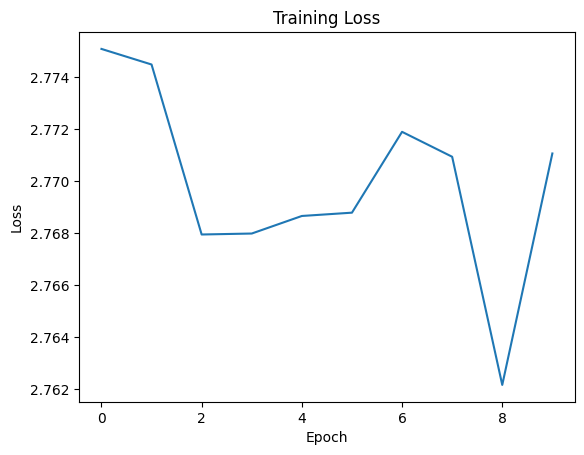

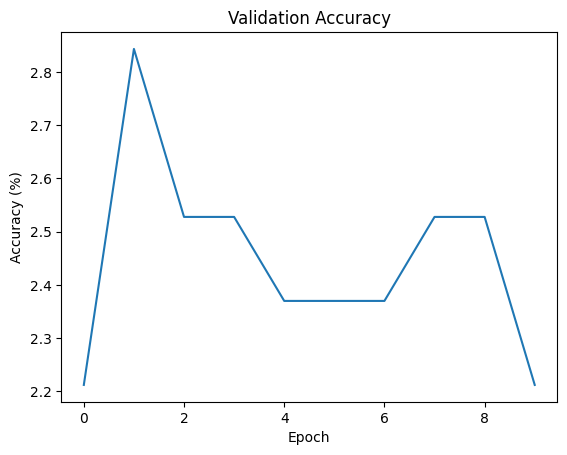

In [58]:
import matplotlib.pyplot as plt

# Loss
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()

In [59]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"✅ Final Validation Accuracy: {100 * correct / total:.2f}%")

✅ Final Validation Accuracy: 2.21%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       101
           1       0.05      0.16      0.07        43
           2       0.00      0.00      0.00        24
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        19
           5       0.50      0.03      0.06       131
           6       0.07      0.04      0.05        23
           7       1.00      0.01      0.02        83
           8       0.02      0.03      0.03        31
           9       0.00      0.00      0.00       130
          10       0.00      0.00      0.00        24
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0

    accuracy                           0.02       633
   macro avg       0.12      0.02      0.02       633
weighted avg       0.24      0.02      0.02       633



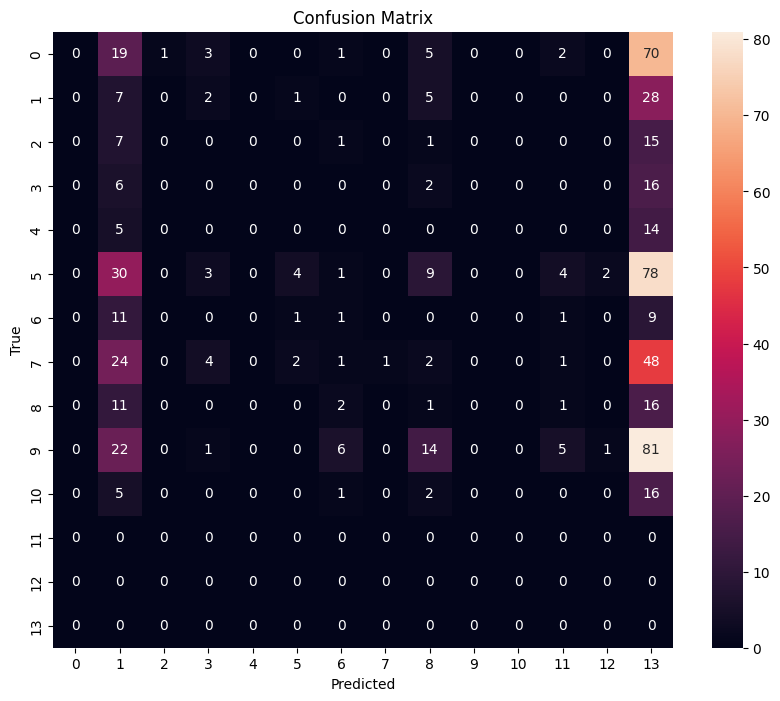

In [60]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [61]:
from PIL import Image
import numpy as np

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224,224))
    img = np.array(img) / 255.0
    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return pred.item()

# Example
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0001_aligned.jpg"
print("Predicted label:", predict_image(img_path))

Predicted label: 1
